# Supervised Causal Variable Localization with DAS and DBM

In the previous notebook we used activation patching to trace *where* information flows through the residual stream. Patching the full hidden-state vector is a coarse instrument: it swaps everything at a position, not just the signal relevant to one variable. Two complementary refinements live in this notebook:

- **Distributed Alignment Search (DAS)** finds a small linear *subspace* of the residual stream that carries one causal variable. Same site, fewer dimensions.
- **Desiderata-Based Masking (DBM)** finds which *components* (attention heads, MLPs) the variable flows through. Different sites, whole units selected on/off.

The combination answers: not just where information lives, but along which directions and through which components.

In this notebook you will:
1. Train and inspect a single-cell DAS subspace via `train_interventions` directly
2. Compare against a full-vector patching baseline produced by the `locate` analysis
3. Run the `subspace` analysis end-to-end to scan a (layer × position) DAS grid
4. Run `subspace` with DBM over attention heads and MLPs to pick out the components carrying the answer

In [1]:
# PARAMETERS
MODEL_NAME = "meta-llama/Llama-3.2-1B-Instruct"
MAX_NEW_TOKENS = 1
DATASET_SIZE = 64  # counterfactual examples per split (train and test)

from typing import Any

import torch
from causalab.neural.pipeline import LMPipeline
from causalab.tasks.MCQA.causal_models import positional_causal_model

device = "cuda" if torch.cuda.is_available() else "cpu"
pipeline = LMPipeline(
    MODEL_NAME,
    max_new_tokens=MAX_NEW_TOKENS,
    device=device,
    dtype=torch.bfloat16 if device == "cuda" else torch.float32,
)
print("DEVICE:", pipeline.model.device)

causal_model = positional_causal_model


def checker(neural_output: dict[str, Any], causal_output: str) -> bool:
    """Return True if the model's string output matches the expected causal output."""
    return (
        causal_output in neural_output["string"]
        or neural_output["string"] in causal_output
    )

`torch_dtype` is deprecated! Use `dtype` instead!
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


DEVICE: cuda:0


## Generating and filtering counterfactual datasets

DAS training requires pairs of inputs that differ in exactly one causal variable. We use three counterfactual generators from the MCQA task:

- **`different_symbol`** — moves the correct answer to a different label (A→C). Tests whether the model can follow the correct label.
- **`same_symbol_different_position`** — keeps the correct label but shuffles which answer is at which position. Tests positional encoding of the answer.
- **`random_counterfactual`** — randomizes all causal variables. Serves as a baseline.

After sampling, `filter_dataset` runs both the base and counterfactual prompts through the model and keeps only pairs where the model answers both correctly. This ensures we train and evaluate on signal the model actually knows — not noise from prompts it gets wrong.

We generate separate train and test datasets to measure generalization. DAS uses gradient descent, so a train-only score is not reliable.

In [2]:
from causalab.causal.counterfactual_dataset import CounterfactualExample
from causalab.tasks.MCQA.counterfactuals import (
    different_symbol,
    same_symbol_different_position,
    random_counterfactual,
)
from causalab.methods.filter import filter_dataset

counterfactual_generators = {
    "different_symbol": different_symbol,
    "same_symbol_different_position": same_symbol_different_position,
    "random_counterfactual": random_counterfactual,
}

# --- Training datasets ---
print("Generating and filtering training datasets...")
train_filtered_datasets: dict[str, list[CounterfactualExample]] = {}
for name, sampler in counterfactual_generators.items():
    raw = [sampler() for _ in range(DATASET_SIZE)]
    train_filtered_datasets[name] = filter_dataset(
        dataset=raw,
        pipeline=pipeline,
        causal_model=causal_model,
        metric=checker,
        batch_size=32,
    )
    print(f"  {name}: {len(train_filtered_datasets[name])} / {DATASET_SIZE} kept")

# --- Test datasets ---
print("\nGenerating and filtering test datasets...")
test_filtered_datasets: dict[str, list[CounterfactualExample]] = {}
for name, sampler in counterfactual_generators.items():
    raw = [sampler() for _ in range(DATASET_SIZE)]
    test_filtered_datasets[name] = filter_dataset(
        dataset=raw,
        pipeline=pipeline,
        causal_model=causal_model,
        metric=checker,
        batch_size=32,
    )
    print(f"  {name}: {len(test_filtered_datasets[name])} / {DATASET_SIZE} kept")

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Generating and filtering training datasets...
  different_symbol: 60 / 64 kept
  same_symbol_different_position: 53 / 64 kept
  random_counterfactual: 61 / 64 kept

Generating and filtering test datasets...
  different_symbol: 58 / 64 kept
  same_symbol_different_position: 60 / 64 kept
  random_counterfactual: 59 / 64 kept


## Learning a DAS subspace at a single (layer, position) cell

The residual stream at layer 10, last-token position is a 2048-dimensional vector (for Llama-3.2-1B). Full-vector patching swaps all 2048 dimensions at once. DAS asks a more precise question: **does there exist a k-dimensional subspace of those 2048 dimensions that is sufficient to carry the causal variable?**

To find it, we:
1. Pick one (layer, position) cell — here, layer 10 at the `last_token` position, which activation patching suggested was important
2. Build an `InterchangeTarget` that hooks into the residual stream at that cell
3. Call `train_interventions(intervention_type="interchange")` — this initializes k orthogonal feature vectors, then trains them by minimizing the distance between the model's output under subspace patching and the causal model's predicted output

The `n_features` parameter controls the subspace dimension k. Start small (16) — more features means more expressive but also more prone to overfitting on small datasets.

In [3]:
# PARAMETERS
DAS_LAYER = 10           # which layer to hook into
DAS_POSITION = "last_token"  # which token position
N_FEATURES = 16          # subspace dimension k
TRAINING_EPOCH = 3       # training epochs
INIT_LR = 0.001          # learning rate
BATCH_SIZE = 32          # train and eval batch size

from causalab.neural.activations import build_residual_stream_targets
from causalab.tasks.MCQA.token_positions import create_token_positions
from causalab.methods.trained_subspace.train import train_interventions
from causalab.runner.configs.train_config import merge_with_defaults

# Build token position objects from the MCQA task's predefined positions
all_token_positions = create_token_positions(pipeline)
print("Available token positions:", list(all_token_positions.keys()))

# Build residual-stream InterchangeTargets for one (layer, position) cell
# build_residual_stream_targets returns a dict keyed by (layer, token_position_id)
targets = build_residual_stream_targets(
    pipeline=pipeline,
    layers=[DAS_LAYER],
    token_positions=[all_token_positions[DAS_POSITION]],
)
print(f"\nBuilt {len(targets)} target(s): {list(targets.keys())}")

# Pull out the single target for this cell
target_key = (DAS_LAYER, all_token_positions[DAS_POSITION].id)
single_target = targets[target_key]
print(f"Target: {single_target}")

Available token positions: ['correct_symbol', 'correct_symbol_period', 'symbol0', 'symbol0_period', 'symbol1', 'symbol1_period', 'last_token']

Built 1 target(s): [(10, 'last_token')]
Target: InterchangeTarget(1 groups, 1 total units)


## Training the DAS subspace

We now call `train_interventions` with `intervention_type="interchange"` (the DAS mode). The config dict is built with `merge_with_defaults`, which fills in all required keys from the system defaults — you only need to override what you want to change.

`target_variable_group=("answer_position",)` tells the training loop which causal variable to optimize for. The causal model evaluates whether the patched output matches what would happen if you swapped the `answer_position` variable in the causal model.

In [4]:
# Build a fully-resolved config by merging our overrides with system defaults.
# merge_with_defaults fills in every required key so train_interventions never
# sees a KeyError.  Only override what you want to change.
das_config = merge_with_defaults({
    "intervention_type": "interchange",  # DAS mode (vs. "mask" for DBM)
    "DAS": {"n_features": N_FEATURES},   # subspace dimension k
    "train_batch_size": BATCH_SIZE,
    "evaluation_batch_size": BATCH_SIZE,
    "training_epoch": TRAINING_EPOCH,
    "init_lr": INIT_LR,
})

# train_interventions accepts a single InterchangeTarget or a dict of targets.
# We pass the single target; the function wraps it internally.
das_result = train_interventions(
    causal_model=causal_model,
    interchange_targets=single_target,
    train_dataset=train_filtered_datasets["same_symbol_different_position"],
    test_dataset=test_filtered_datasets["same_symbol_different_position"],
    pipeline=pipeline,
    target_variable_group=("answer_position",),
    metric=checker,
    config=das_config,
)

print(f"\nDAS results at layer {DAS_LAYER}, position '{DAS_POSITION}':")
print(f"  Train accuracy: {das_result['avg_train_score']:.3f}")
print(f"  Test  accuracy: {das_result['avg_test_score']:.3f}")
print(f"  Train-test gap: {das_result['avg_train_score'] - das_result['avg_test_score']:.3f}")


DAS results at layer 10, position 'last_token':
  Train accuracy: 0.717
  Test  accuracy: 0.683
  Train-test gap: 0.034


## The train-test gap: generalization vs. overfitting

DAS is gradient descent, which means it *can* overfit. A high train score with a low test score means the learned subspace is exploiting dataset-specific patterns rather than a general representation of the variable.

**How to diagnose overfitting:**
- Small gap (< 0.05): the subspace generalizes well — this is a real finding
- Moderate gap (0.05–0.2): normal for small datasets; check with more data
- Large gap (> 0.2): likely overfit; try fewer `N_FEATURES`, more `DATASET_SIZE`, or switch to PCA (unsupervised baseline)

The test score is the ground truth. Training scores are optimistic by construction.

Try re-running the cell above with `TRAINING_EPOCH = 10` to watch the gap grow as the model overfits. Then try `N_FEATURES = 4` to see how few directions can still capture the variable.

## What to look for

The single-cell DAS result you just computed tells you whether the `answer_position` variable has a concentrated linear representation at layer 10, last-token position.

**Interpreting the numbers:**
- **Test accuracy > 0.8**: strong evidence that a 16-dimensional subspace at this cell is sufficient. The variable is linearly encoded here.
- **Test accuracy ≈ 0.5**: variable is not well-concentrated at this cell. Try a different layer (earlier layers may catch it at the input token; later at the output token).
- **Test accuracy ≈ 1.0 with N_FEATURES = 4**: the encoding is very low-dimensional — a strong, clean finding.

**Experiment ideas:**
- Change `DAS_LAYER` to 5 or 15 — how does the accuracy change across layers?
- Change `DAS_POSITION` to `"correct_symbol"` — does accuracy drop or stay high?
- Switch the `target_variable_group` to `("answer",)` (the actual answer content, not its position) and use `different_symbol` datasets — what changes?
- Lower `N_FEATURES` to 1 — is a single direction enough?

---

## Comparison: full-vector patching as a baseline

The single-cell DAS score above measures whether the model can be steered to the counterfactual's expected output by swapping a `k=16`-dim subspace at a single site. It's natural to ask: how does that compare to swapping the *entire* hidden state at every (layer, position) cell? That is what **full-vector patching** does — and it is what the `locate` analysis produces.

We run it here for two target variables:

- `answer_position` — the index (0..3) of the correct choice
- `answer` — the actual answer content

`locate` with `mode: centroid` patches each (layer, position) cell, scores the patched output's KL distance to per-class reference distributions, and aggregates into a heatmap. A bright cell means full-vector patching at that site is enough to swap the model's prediction toward the counterfactual class. The DAS subspace you trained above narrows that signal down to a handful of directions.

In [ ]:
import os
import subprocess
import causalab
from omegaconf import OmegaConf
from causalab.io.configs import load_runner_config

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

# `04_locate_demo.yaml` runs full-vector interchange patching once per target variable.
rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "04_locate_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"locate run failed with return code {rc.returncode}")

locate_cfg = load_runner_config("04_locate_demo")
locate_dir = os.path.join(
    project_root, locate_cfg.experiment_root, "locate", locate_cfg.locate._subdir,
)
print(f"\nLocate output directory: {locate_dir}")
print("Per-variable subdirs:", sorted(os.listdir(locate_dir)))

In [ ]:
from IPython.display import Image, display

for variable in locate_cfg.task.target_variables:
    heatmap_path = os.path.join(locate_dir, variable, "heatmap.png")
    if os.path.exists(heatmap_path):
        print(f"Full-vector patching: target_variable = {variable!r}")
        display(Image(filename=heatmap_path))
    else:
        print(f"Heatmap not found at {heatmap_path}")

---

## From exploration to analysis

The supervised training above finds an optimal subspace *for a single (layer, position) cell*. A research question lives at the level of populations: **across all (layer, token_position) sites in the model, which ones most efficiently encode the causal variable, and what is the minimal subspace dimension needed?**

Answering that requires:

- Scanning a (layer × token_position) grid rather than one cell at a time
- Evaluating every cell with the same train/test split and aggregating scores into a heatmap
- Running with reproducible hyperparameters stored in version control
- Saving artifacts (rotation matrices, grid scores, scatter plots) for downstream analyses (`activation_manifold`, `path_steering`)

This is exactly what the **`subspace` analysis** does. Under the hood it calls the same `train_interventions()` you just wrote — packaged behind a Hydra config that becomes the single source of truth for every parameter. The rest of this notebook shows how to define that config and run `subspace` end-to-end across the full grid.

## Running `subspace` end-to-end

The config below defines a complete runner preset for the `subspace` analysis. Edit any field and re-run the cell to update the config file.

| Field | What it controls |
|---|---|
| `method` | `das` (learned rotation), `pca` (unsupervised), `dbm` (binary masks), or `boundless` |
| `k_features` | Number of dimensions in the subspace |
| `layers` | List of layers to scan; `null` auto-resolves best layer from `locate/` artifacts |
| `das.training_epoch` | DAS training iterations per cell |
| `das.lr` | DAS learning rate |
| `enumerate_all` | `true` = use every possible MCQA input (small task, deterministic results) |
| `figure_format` | `png` for inline notebook display, `pdf` for publication |

We use `method: das` here because that is what you trained by hand in Section 1 — the grid heatmap will show the same training algorithm running across all (layer, position) cells. If you've already run `locate`, you can set `layers: null` to auto-resolve the best cell and run in single-cell mode instead of grid mode.

In [5]:
config_yaml = """\
defaults:
  - base
  - task: MCQA
  - model: llama32_1b_instruct
  - analysis/subspace
  - _self_
task:
  enumerate_all: true  # use all possible MCQA inputs (small task — exhaustive is fast)
  target_variables: [answer_position]

subspace:
  method: das
  k_features: 16
  layers: [0, 5, 10, 15]  # scan 4 layers; set null to auto-resolve from locate/
  das:
    training_epoch: 4
    lr: 0.001
  visualization:
    figure_format: png
"""

In [6]:
from causalab.io.configs import save_runner_config, load_runner_config

path = save_runner_config(config_yaml, "subspace_tutorial_das")
print(f"Written to {path}\n")

cfg = load_runner_config("subspace_tutorial_das")
print("Full resolved Hydra config:")
print(OmegaConf.to_yaml(cfg))

Written to causalab/runner/configs/runner/subspace_tutorial_das.yaml

Full resolved Hydra config:
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variables:
  - answer_position
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
seed: 42
code_trace: false
experiment_root: artifacts/${task.name}/${model.id}
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: das
  k_features: 16
  batch_size: 32
  layers:
  - 0
  - 5
  - 10
  - 15
  token_positions: null
  visualization:
    figure_format: png
    colormap: ${task.colormap}
    vis_dims: null
    detailed_hover: false
    max_hover_chars: 50
  das:
    training_epoch: 4
    lr: 0.001
  dbm:
    training_epoch: 20
    lr: 0.001
    regularization_coefficient

The resolved config print above shows every default that Hydra merged in. Check that the merged defaults make sense.

Run the analysis via `scripts/run_exp.sh`. The grid scan trains DAS at each (layer, position) cell and saves all artifacts to `artifacts/MCQA/llama32_1b_instruct/subspace/das_k16/`. On a single A100 with 4 layers and all MCQA positions this takes around 5–10 minutes.

In [8]:
import os
import subprocess
import causalab

project_root = os.path.dirname(os.path.dirname(causalab.__file__))

rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "subspace_tutorial_das"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"Experiment failed with return code {rc.returncode}")

[2026-04-21 18:37:14,987][__main__][INFO] - === Step: subspace (subspace) ===
[2026-04-21 18:37:23,941][__main__][INFO] - Running analysis: subspace | target_variable: answer_position
[2026-04-21 18:37:23,944][__main__][INFO] - Resolved config:
task:
  name: MCQA
  intervention_metric: string_match
  max_new_tokens: 1
  colormap: viridis
  n_train: 1000
  n_test: 50
  enumerate_all: true
  balanced: false
  resample_variable: all
  target_variables:
  - answer_position
  target_variable: answer_position
model:
  id: llama32_1b_instruct
  name: meta-llama/Llama-3.2-1B-Instruct
  device: auto
  dtype: bfloat16
seed: 42
code_trace: false
experiment_root: artifacts/${task.name}/${model.id}
subspace:
  _name_: subspace
  _subdir: ${.method}_k${.k_features}
  _output_dir: ${experiment_root}/subspace/${._subdir}
  method: das
  k_features: 16
  batch_size: 32
  layers:
  - 0
  - 5
  - 10
  - 15
  token_positions: null
  visualization:
    figure_format: png
    colormap: ${task.colormap}
    

`torch_dtype` is deprecated! Use `dtype` instead!
Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


[2026-04-21 18:37:26,357][huggingface_hub.file_download][ERROR] - Could not cache non-existence of file. Will ignore error and continue. Error: [Errno 13] Permission denied: '~/.cache/huggingface/hub/models--meta-llama--Llama-3.2-1B-Instruct/.no_exist/9213176726f574b556790deb65791e0c5aa438b6/custom_generate/generate.py'


Training InterchangeTarget(1 groups, 1 total units)...:   0%|          | 0/4 [00:00<?, ?it/s]
Epoch: 0:  97%|█████████▋| 31/32 [00:03<00:00, 13.19it/s, loss=5.8, accuracy=0.43, token_accuracy=0.43] 
Training InterchangeTarget(1 groups, 1 total units)...:  25%|██▌       | 1/4 [00:03<00:09,  3.04s/it, loss=5.8037, accuracy=0.2116, token_accuracy=0.2116]
Epoch: 1: 100%|██████████| 32/32 [00:01<00:00, 18.91it/s, loss=0.44, accuracy=1, token_accuracy=1]
Training InterchangeTarget(1 groups, 1 total units)...:  50%|█████     | 2/4 [00:04<00:04,  2.24s/it, loss=0.4409, accuracy=0.9326, token_accuracy=0.9326]
Epoch: 2: 100%|██████████| 32/32 [00:01<00:00, 19.10it/s, loss=0.23, accuracy=1, token_accuracy=1]
Training InterchangeTarget(1 groups, 1 total units)...:  75%|███████▌  | 3/4 [00:06<00:01,  1.99s/it, loss=0.2333, accuracy=0.9883, token_accuracy=0.9883]
Epoch: 3: 100%|██████████| 32/32 [00:01<00:00, 19.21it/s, loss=0.19, accuracy=1, token_accuracy=1]
The following generation flags are not 

[2026-04-21 18:42:18,802][causalab.analyses.subspace.grid][INFO] - DAS grid complete. Avg train=0.276, avg test=0.244
[2026-04-21 18:42:21,141][causalab.analyses.subspace.main][INFO] - Grid best cell: (layer=0, position=correct_symbol) score=1.0000
[2026-04-21 18:42:21,408][causalab.analyses.subspace.main][INFO] - Subspace analysis complete. Output in artifacts/MCQA/llama32_1b_instruct/subspace/das_k16/answer_position


## Artifacts

All outputs land in `artifacts/{task}/{model}/subspace/{method}_k{k}/`. The path is derived from the resolved config — never hardcoded.

In [9]:
import json

# The runner saves one subdirectory per target variable, so we append it here.
target_variable = cfg.task.target_variables[0]
artifact_dir = os.path.join(
    project_root, cfg.experiment_root, "subspace", cfg.subspace._subdir,
    target_variable,
)
print(f"Artifact directory: {artifact_dir}\n")
print("Contents:", sorted(os.listdir(artifact_dir)))

# Load metadata
with open(os.path.join(artifact_dir, "metadata.json")) as f:
    metadata = json.load(f)

print(f"\nAnalysis mode:  {metadata.get('mode')}")
print(f"Method:         {metadata.get('method')}")
print(f"k_features:     {metadata.get('k_features')}")
print(f"Best cell:      {metadata.get('best_cell')}")

Artifact directory: artifacts/MCQA/llama32_1b_instruct/subspace/das_k16/answer_position

Contents: ['grid_results.json', 'heatmaps', 'logs', 'metadata.json', 'models', 'test_eval', 'train_dataset.json', 'train_eval', 'training']

Analysis mode:  grid
Method:         das
k_features:     16
Best cell:      {'layer': 0, 'token_position': 'correct_symbol'}


### Grid heatmap: where is the variable encoded?

The test heatmap shows DAS accuracy across the (layer × token_position) grid. Each cell's value is the fraction of held-out examples where patching within the learned k=16 subspace caused the model to output the counterfactual's correct answer.

**What to look for:**
- **A clear peak**: the variable has a focused linear encoding at one cell — this is the best target for downstream analyses
- **A row-wide bright band**: information is broadcast across all token positions at that layer by an attention head
- **Fade from early to late layers**: variable arrives at the input token in early layers, then gets routed to the last token by attention

The `subspace` analysis uses the same `train_interventions(..., intervention_type="interchange")` you called in Section 1 — the only difference is that it runs it for every cell in the grid and aggregates the test scores into this heatmap.

DAS test accuracy heatmap:


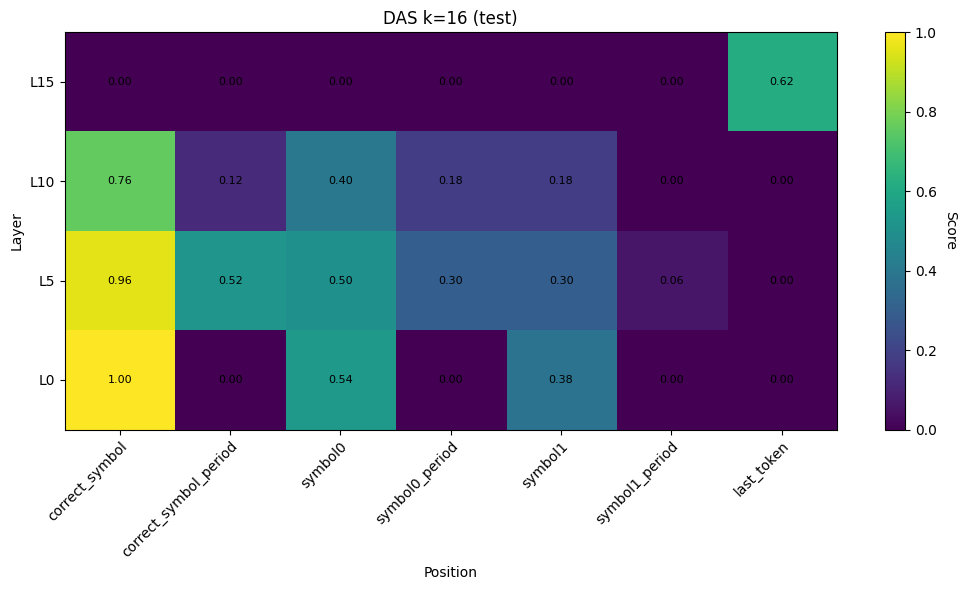


Top 10 cells by DAS test accuracy:
Layer  Position                        Test score
----------------------------------------------------
    0  correct_symbol                      1.0000
    5  correct_symbol                      0.9600
   10  correct_symbol                      0.7600
   15  last_token                          0.6200
    0  symbol0                             0.5400
    5  correct_symbol_period               0.5200
    5  symbol0                             0.5000
   10  symbol0                             0.4000
    0  symbol1                             0.3800
    5  symbol0_period                      0.3000


In [10]:
from IPython.display import Image, display

heatmaps_dir = os.path.join(artifact_dir, "heatmaps")
test_heatmap_path = os.path.join(heatmaps_dir, "test.png")

if os.path.exists(test_heatmap_path):
    print("DAS test accuracy heatmap:")
    display(Image(filename=test_heatmap_path))
else:
    print(f"Heatmap not found at {test_heatmap_path}")
    print("Available files:", sorted(os.listdir(heatmaps_dir)) if os.path.isdir(heatmaps_dir) else "heatmaps/ dir not found")

# Also show ranked top-10 cells by test score
grid_path = os.path.join(artifact_dir, "grid_results.json")
if os.path.exists(grid_path):
    with open(grid_path) as f:
        grid_data = json.load(f)

    scores = grid_data.get("scores_per_cell", {})
    ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]
    print("\nTop 10 cells by DAS test accuracy:")
    print(f"{'Layer':>5}  {'Position':<30}  {'Test score':>10}")
    print("-" * 52)
    for cell_key, score in ranked:
        layer, pos = cell_key.split("|", 1)
        print(f"{layer:>5}  {pos:<30}  {score:>10.4f}")

### Train vs. test: detecting overfitting at scale

The training heatmap shows the same grid but scored on training data. Comparing it to the test heatmap reveals which cells are truly informative versus which ones the optimizer found shortcuts for.

- **Test ≈ Train everywhere**: DAS is not overfitting; the dataset is large enough or the task is easy enough that generalization is clean
- **Train bright, Test dim at the same cell**: that cell is memorized, not generalized — trust the test heatmap, not the training one
- **Both bright at the same cell**: genuine finding — that cell encodes the variable

Small datasets (64 examples per split) make this gap more visible. The grid version has the same problem as the single-cell run: each cell's DAS is trained on its own copy of the dataset.

DAS train accuracy heatmap (compare to test above):


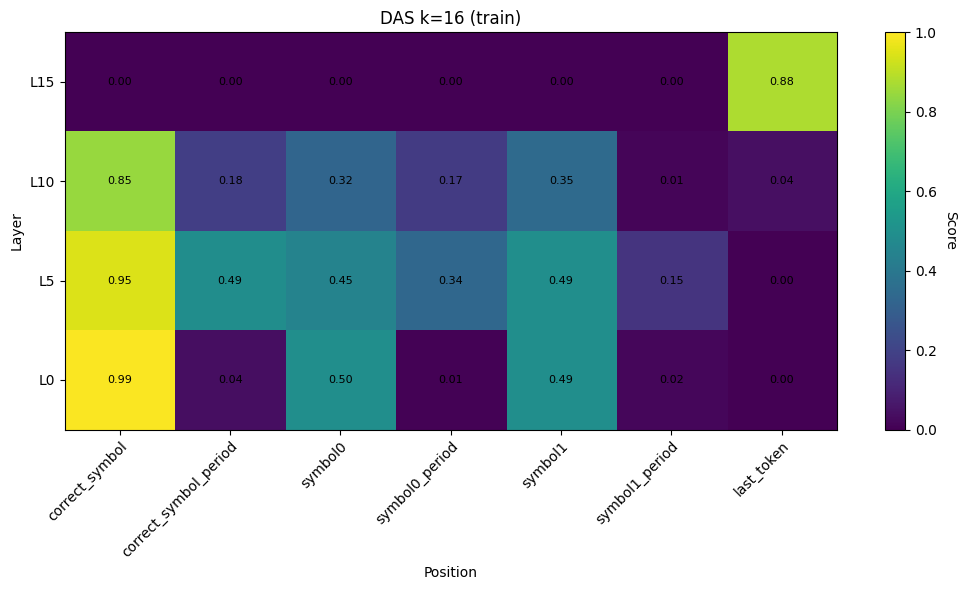

In [11]:
train_heatmap_path = os.path.join(heatmaps_dir, "train.png")
if os.path.exists(train_heatmap_path):
    print("DAS train accuracy heatmap (compare to test above):")
    display(Image(filename=train_heatmap_path))
else:
    print(f"Train heatmap not found at {train_heatmap_path}")

### Best-cell model artifacts

The analysis saves the trained featurizer (rotation matrix) for every (layer, position) cell in `models/{layer}__{position}/`. The best cell's `units_metadata.json` records the shape of the original hidden state and how many DAS directions were learned.

Note: 2D/3D scatter plots projecting examples into the learned subspace are only generated by the `pca` method. For DAS, those plots live in the `activation_manifold` analysis that runs after `subspace`.

In [12]:
best_cell = metadata.get("best_cell")
if best_cell:
    best_layer = best_cell["layer"]
    best_pos = best_cell["token_position"]
    print(f"Best cell: layer {best_layer}, position '{best_pos}'")

    cell_dir = os.path.join(artifact_dir, "models", f"{best_layer}__{best_pos}")
    units_meta_path = os.path.join(cell_dir, "units_metadata.json")

    if os.path.exists(units_meta_path):
        with open(units_meta_path) as f:
            units_meta = json.load(f)
        unit_info = next(iter(units_meta.values()))
        feat_info = unit_info.get("featurizer_info", {})
        print(f"\nFeaturizer: {feat_info.get('id')}")
        print(f"  n_features (k):  {feat_info.get('n_features')}")
        print(f"  trivial (k=full dim): {feat_info.get('is_trivial')}")
        print(f"  hidden state shape:   {unit_info.get('shape')}")
    else:
        print(f"units_metadata.json not found at {units_meta_path}")
        if os.path.isdir(cell_dir):
            print("  Files in best cell dir:", sorted(os.listdir(cell_dir)))
        else:
            print("  Best cell dir not found:", cell_dir)
else:
    print("No best_cell in metadata.")

Best cell: layer 0, position 'correct_symbol'

Featurizer: DAS_ResidualStream(Layer-0,block_output,Token-correct_symbol)
  n_features (k):  16
  trivial (k=full dim): False
  hidden state shape:   [2048]


---

## Selecting components with DBM

DAS asks: *along which directions in the residual stream is the variable encoded?* The complementary question is: *which components — attention heads or MLPs — are the ones routing that information?* For that we use **Desiderata-Based Masking (DBM)**: a binary mask is trained over the outputs of every unit, and the optimizer keeps only the units required to flip the model's answer to the counterfactual's.

We use the same `subspace` analysis but with two changes via the `modes:` sweep:

- `component_type: attention_head` — the unit is one (layer, head); the heatmap axes are layer × head.
- `component_type: mlp` — the unit is one (layer, token_position); the heatmap axes are layer × position.

`dbm.tie_masks: true` means each unit gets a single binary on/off decision, so the rendered heatmap shows precisely which heads / MLPs were selected.

In [ ]:
# `04_subspace_dbm_components_demo.yaml` runs subspace.method=dbm twice via modes:
#   - dbm_attention: layers × heads at last_token
#   - dbm_mlp:       layers × {correct_symbol, correct_symbol_period, last_token}
rc = subprocess.run(
    ["bash", "scripts/run_exp.sh", "04_subspace_dbm_components_demo"],
    cwd=project_root,
)
if rc.returncode != 0:
    raise Exception(f"DBM components run failed with return code {rc.returncode}")

dbm_cfg = load_runner_config("04_subspace_dbm_components_demo")
dbm_root = os.path.join(
    project_root, dbm_cfg.experiment_root, "subspace", dbm_cfg.subspace._subdir,
)
print(f"\nDBM components output directory: {dbm_root}")
print("Mode subdirs:", sorted(os.listdir(dbm_root)))

In [ ]:
target_variable = dbm_cfg.task.target_variable

for mode_name, label in [
    ("dbm_attention", "DBM over attention heads (layer × head)"),
    ("dbm_mlp",       "DBM over MLPs (layer × token_position)"),
]:
    heatmap_path = os.path.join(
        dbm_root, mode_name, target_variable, "heatmaps", "feature_counts.png",
    )
    if os.path.exists(heatmap_path):
        print(label)
        display(Image(filename=heatmap_path))
    else:
        print(f"Heatmap not found at {heatmap_path}")
        mode_dir = os.path.join(dbm_root, mode_name, target_variable)
        if os.path.isdir(mode_dir):
            heatmaps_dir = os.path.join(mode_dir, "heatmaps")
            print(
                "  Available files:",
                sorted(os.listdir(heatmaps_dir)) if os.path.isdir(heatmaps_dir) else os.listdir(mode_dir),
            )

## Takeaway

You used three complementary lenses on the same model:

- **Full-vector patching (`locate`)** — the coarse baseline. Bright cells say *something* at this site is enough to flip the answer; doesn't say what.
- **DAS (`subspace`, `method: das`)** — narrows the bright cells of `locate` down to a `k`-dim subspace. Test accuracy ≈ `locate` test accuracy at the same cell means a small linear address suffices; a large gap means the variable lives in a higher-dimensional or non-linear submanifold.
- **DBM (`subspace`, `method: dbm`, `tie_masks: true`)** — zooms out from the residual stream to *components*. The selected attention heads are the routers that move the answer to the last-token position; the selected MLPs are where it gets transformed into the form the unembedding can read.

If the three views agree (a `locate` peak at layer L, a clean DAS subspace at layer L, and DBM-selected heads writing into layer L), you have a robust localization. If they disagree, the discrepancy is itself a finding — usually pointing at variance-only structure (DAS without DBM agreement) or distributed encoding (DBM without DAS agreement).

**What comes next:**
- `activation_manifold` — fit geometric models to the variable's structure within the DAS subspace at the best cell.
- `path_steering` — verify that the subspace faithfully preserves causal structure by steering along it.

For the full `subspace` walkthrough including all four methods (DAS, PCA, DBM, boundless DAS), multi-variable analysis, and layer-scan strategies: see `causalab/analyses/subspace/demo.ipynb`.